# preprocessing:

In [24]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# load datasets:
with open("datasetss/mnist.pkl", "rb") as f:
    mnist= pickle.load(f)

with open("datasetss/mnistm.pkl", "rb") as f:
    mnistm= pickle.load(f)



In [25]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [26]:
print(mnist)

{b'images': array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0,

In [27]:
print(mnistm)

{b'images': array([[[[ 60,  77, 133],
         [ 61,  78, 134],
         [ 62,  79, 135],
         ...,
         [ 57,  76, 132],
         [ 57,  76, 132],
         [ 57,  77, 130]],

        [[ 60,  77, 133],
         [ 61,  78, 134],
         [ 61,  78, 134],
         ...,
         [ 57,  76, 132],
         [ 57,  76, 132],
         [ 57,  76, 132]],

        [[ 61,  78, 134],
         [ 61,  78, 134],
         [ 61,  78, 134],
         ...,
         [ 56,  75, 131],
         [ 56,  75, 131],
         [ 57,  76, 132]],

        ...,

        [[ 57,  76, 134],
         [ 57,  77, 130],
         [ 57,  77, 130],
         ...,
         [  6,  34,  35],
         [  6,  35,  33],
         [  7,  36,  32]],

        [[ 58,  77, 135],
         [ 58,  77, 133],
         [ 57,  77, 130],
         ...,
         [  9,  37,  38],
         [  8,  37,  35],
         [  8,  37,  35]],

        [[ 57,  73, 133],
         [ 62,  78, 137],
         [ 58,  75, 131],
         ...,
         [  8,  37,  3

In [28]:
mnist_images =mnist[b'images']
mnistm_images =mnistm[b'images']
mnist_labels = mnist[b'labels']
mnistm_labels = mnistm[b'labels']

## show 5 random images from databases:

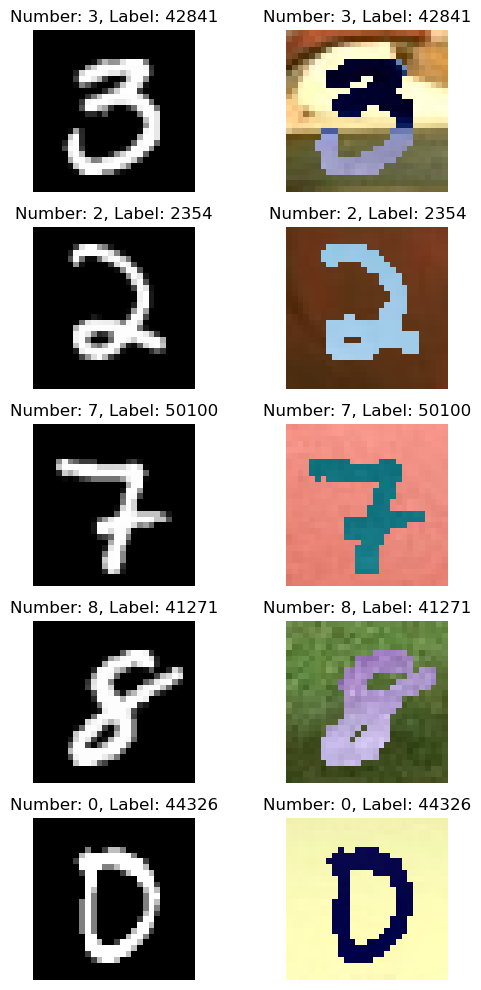

In [29]:
random_idx= np.random.choice(mnist_images.shape[0], size=5, replace=False)
# print(random_idx)

fig, axes = plt.subplots(len(random_idx), 2, figsize=(6, 10))
for i, idx in enumerate(random_idx):
    mnist_image = mnist_images[idx]
    mnistm_image= mnistm_images[idx]
    mnist_label= mnist_labels[idx]
    axes[i, 0].imshow(mnist_image, cmap="gray")
    axes[i, 0].set_title(f"Number: {mnist_label}, Label: {idx}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mnistm_image)
    axes[i, 1].set_title(f"Number: {mnist_label}, Label: {idx}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [30]:
import torch
from torch.utils.data import Dataset,DataLoader, Subset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split

class MyDataset(Dataset):
    def __init__(self, images, labels, transform= None, is_mnist= True): # since I need to do some addtional changes to mnist image, i use is_mnist

        self.images = images
        self.labels = labels
        self.transform= transform
        self.is_mnist= is_mnist 

    def __len__(self):
        return len(self.images)
        
    def __getitem__(self, index):
        image = self.images[index]
        label= int(self.labels[index])

        if self.is_mnist:
            image = Image.fromarray(image, mode='L').convert('RGB')
        else:
            image= Image.fromarray(image)

        image = self.transform(image)

        return image, label


image_size = 32

transform= transforms.Compose([
transforms.Resize((image_size,image_size)),
transforms.ToTensor(),
transforms.Normalize(mean=[0.5]* 3, std = [0.5]*3) # notea that: output=(input - mean)/ std
])

# now choosing sam indices for bot mnist and mnistm:
indices= np.arange(len(mnist_labels))
train_idx, test_idx= train_test_split(indices, test_size= 0.2 , random_state= 42, shuffle=True)


# creating datasets:
mnist_dataset= MyDataset(mnist_images, mnist_labels, transform=transform, is_mnist=True)
mnistm_dataset= MyDataset(mnistm_images, mnistm_labels, transform=transform, is_mnist=False)

mnist_train = Subset(mnist_dataset, train_idx)
mnist_test = Subset(mnist_dataset, test_idx)

mnistm_train = Subset(mnistm_dataset, train_idx)
mnistm_test = Subset(mnistm_dataset, test_idx)


# batch sie:
batch_size = 32
# dataloader:
mnist_train_dataloader= DataLoader(mnist_train, batch_size=batch_size, shuffle=False) #  shuffle=False: I have already shuffled the indices
mnist_test_dataloader= DataLoader(mnist_test, batch_size=batch_size, shuffle=False)


mnistm_train_dataloader= DataLoader(mnistm_train, batch_size=batch_size, shuffle=False) #  shuffle=False: I have already shuffled the indices
mnistm_test_dataloader= DataLoader(mnistm_test, batch_size=batch_size, shuffle=False)

# define parts of the model

In [31]:
# classifier:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        # before fully connected part:
        self.net = nn.Sequential(
            #private:
            nn.Conv2d(3, 32, kernel_size=5),
            nn.ReLU(inplace=True), # i use inplace = true to save the mamory
            nn.MaxPool2d(2, 2),
            # shared
            nn.Conv2d(32, 48, kernel_size=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        # fuly connected part:
        self.fc = nn.Sequential(
            # nn.Flatten(),
            nn.Linear(48 * 5 * 5, 100),
            nn.ReLU(inplace=True),
            nn.Linear(100, 100),
            nn.ReLU(inplace=True),
            nn.Linear(100, 10) 
        )

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [32]:
# generator:

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, stride=1 ,padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, stride=1,padding=1),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):
        # return F.relu(x + self.conv_block(x))
        return x + self.conv_block(x)


class Generator(nn.Module):
    def __init__(self, noise_dim=10, image_size=image_size):
        super().__init__()
        self.noise_dim = noise_dim
        self.image_size = image_size

        # noise fc layer:
        self.z_fc = nn.Sequential(
        nn.Linear(noise_dim, image_size * image_size),
        # nn.BatchNorm1d(image_size * image_size),
        nn.LeakyReLU(0.2, inplace=True)
        )
        
        # first conv: n64 s1
        self.input_conv = nn.Sequential(
            nn.Conv2d(3+1, 64, kernel_size=3, padding=1, stride=1),
            # nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        # 6 residual block:
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(64) for _ in range(6)]
        )

        # last conv layer
        self.output_conv = nn.Sequential(
            nn.Conv2d(64, 3, kernel_size=3,stride=1, padding=1),
            nn.Tanh()  
        )

    def forward(self, x, z):
        batch_size = x.size(0)

        # print(f"sum z is: {z.sum()}")

        z_map = self.z_fc(z) 
        z_map = z_map.view(batch_size, 1, self.image_size, self.image_size) # reshape z_fc to image shape
        
        x_input = torch.cat([x, z_map], dim=1)

        # print(f"sum z_map is: {z_map.sum()}")

        x = self.input_conv(x_input)
        x = self.res_blocks(x)
        x = self.output_conv(x)
        return x
    
# class Generator(nn.Module): # higher noise
#     def __init__(self, noise_dim=10, image_size=image_size):
#         super().__init__()
#         self.noise_dim = noise_dim
#         self.image_size = image_size

#         # noise fc layer:
#         self.z_fc = nn.Sequential(
#         nn.Linear(noise_dim, 3*image_size * image_size),
#         nn.BatchNorm1d(3*image_size * image_size),
#         nn.LeakyReLU(0.5, inplace=True)
#         )
        
#         # first conv: n64 s1
#         self.input_conv = nn.Sequential(
#             nn.Conv2d(3+3, 64, kernel_size=3, padding=1, stride=1)
#             nn.BatchNorm2d(64),
#             nn.ReLU(inplace=True)
#         )

#         # 6 residual block:
#         self.res_blocks = nn.Sequential(
#             *[ResidualBlock(64) for _ in range(6)]
#         )

#         # last conv layer
#         self.output_conv = nn.Sequential(
#             nn.Conv2d(64, 3, kernel_size=3,stride=1, padding=1),
#             nn.Tanh()  
#         )

#     def forward(self, x, z):
#         batch_size = x.size(0)

#         # print(f"sum z is: {z.sum()}")

#         z_map = self.z_fc(z) 
#         z_map = z_map.view(batch_size, 3, self.image_size, self.image_size) # reshape z_fc to image shape
#         x_input = torch.cat([x, z_map], dim=1)

#         # print(f"sum z_map is: {z_map.sum()}")

#         x = self.input_conv(x_input)
#         x = self.res_blocks(x)
#         x = self.output_conv(x)
#         return x


In [33]:
# discriminator

class GaussianNoise(nn.Module): # according to section B of the paper: Inject noise drawn from a zero centered Gaussian with stddev 0.2 after every layer of discriminator
    def __init__(self, std=0.2):
        super().__init__()
        self.std = std

    def forward(self, x):
        if self.training:  #  add noise only for training 
            noise = torch.randn_like(x) * self.std
            return x + noise
        else:
            return x
    

class Discriminator(nn.Module):
    def __init__(self, input_channels=3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=3, stride=1, padding=1),  # n64s1
            GaussianNoise(std=0.2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.1),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # n128s2
            GaussianNoise(std=0.2),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.1),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),  # n256s2
            GaussianNoise(std=0.2),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.1),

            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1),  # n512s2
            GaussianNoise(std=0.2),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.1),

            # nn.Conv2d(512, 1024, kernel_size=3, stride=2, padding=1),  # n1024s2
            # GaussianNoise(std=0.2),
            # nn.BatchNorm2d(1024),
            # nn.LeakyReLU(0.2, inplace=True),
            # nn.Dropout(0.1),

            nn.Flatten(),
            nn.Linear(8192, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.model(x)
        return x



# loss functions

In [34]:
import torch.nn as nn

def discriminator_loss(discriminator, real_images, fake_images):
    real_preds = discriminator(real_images)
    fake_preds = discriminator(fake_images.detach())  # detach to avoid backpropag  G

    real_labels = torch.ones_like(real_preds) # this trains discriminator to output 1 for real images 
    fake_labels = torch.zeros_like(fake_preds)# this trains  discriminator to output 0 for fake images

    # real_loss = F.binary_cross_entropy(real_preds, real_labels)
    # fake_loss = F.binary_cross_entropy(fake_preds, fake_labels)

    real_loss = F.mse_loss(real_preds, real_labels)
    fake_loss = F.mse_loss(fake_preds, fake_labels)

    return real_loss + fake_loss



def generator_adversarial_loss(discriminator, fake_images):
    preds = discriminator(fake_images)
    target_labels = torch.ones_like(preds)  # wants D(fake) = 1

    # loss = F.binary_cross_entropy(preds, target_labels)
    loss = F.mse_loss(preds, target_labels)
    return loss





def task_classification_loss(classifier, images, labels):
    pred = classifier(images)

    loss = F.cross_entropy(pred, labels)

    return loss


# Define parts of model:

In [35]:
# section B in paper:
# Parameters initialized from zero centered Gaussian with stddev 0.02

def weights_init_normal(m):
    classname = m.__class__.__name__
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.normal_(m.weight.data, mean=0.0, std=0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)


# def weights_init_normal(m):
#     classname = m.__class__.__name__
#     if isinstance(m, (nn.Conv2d)):
#         nn.init.normal_(m.weight.data, mean=0.0, std=0.02)
#         if m.bias is not None:
#             nn.init.constant_(m.bias.data, 0)


In [36]:
generator = Generator()
discriminator = Discriminator()
classifier =Classifier()

# initial weigths according to paper:
generator.apply(weights_init_normal)
discriminator.apply(weights_init_normal)
classifier.apply(weights_init_normal)

# using GPU:
generator.to(device)
discriminator.to(device)
classifier.to(device)


Classifier(
  (net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 48, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=1200, out_features=100, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=100, out_features=10, bias=True)
  )
)

#  settings:

In [37]:
# hyper parameters:
lr = 1e-3 # Base learning rate
weight_decay = 1e-5 # L2 weight decay
beta1 = 0.5 # ADAM optimizer with β1 = 0.5
w_d = 0.13   # weight for discriminator loss
w_c = 0.01    # weight for classification loss
w_g = 0.011  # weight for generator adversarial loss

# w_d = 1  # weight for discriminator loss
# w_c = 0.1    # weight for classification loss
# w_g = 1  # weight for generator adversarial loss
noise_dim = 10

# optimizers:
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999), weight_decay=weight_decay)
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999), weight_decay=weight_decay)
optimizer_T = torch.optim.Adam(classifier.parameters(), lr=lr, betas=(beta1, 0.999), weight_decay=weight_decay)

# learing rate setting:
from torch.optim.lr_scheduler import LambdaLR

decay_fn = lambda step: 0.95 ** (step // 20000) # Learning rate decayed by 0.95 every 20,000 steps
scheduler_D = LambdaLR(optimizer_D, lr_lambda=decay_fn)
scheduler_G = LambdaLR(optimizer_G, lr_lambda=decay_fn)
scheduler_T = LambdaLR(optimizer_T, lr_lambda=decay_fn)




# to save data during training:

In [38]:
def evaluate_losses_accuracy(classifier, generator, discriminator, mnist_loader, mnistm_loader, device=device, noise_dim=10, w_g=w_g, w_c=w_c, w_d=w_d):
    classifier.eval()
    generator.eval()
    discriminator.eval()

    fake_total_correct = 0
    fake_total_samples = 0

    mnist_total_correct = 0
    mnist_total_samples = 0

    mnistm_total_correct = 0
    mnistm_total_samples = 0

    all_task_losses = []
    all_g_losses = []
    all_d_losses = []
    all_total_losses = []

    with torch.no_grad():
        for (mnist_batch, mnistm_batch) in zip(mnist_loader, mnistm_loader):
            mnist_images, labels = mnist_batch
            mnistm_images, _ = mnistm_batch

            mnist_images = mnist_images.to(device)
            mnistm_images = mnistm_images.to(device)
            labels = labels.to(device)
            batch_size = mnist_images.size(0)

            # noise and fake images:
            z = torch.rand(batch_size, noise_dim, device=device) * 2 - 1
            fake_images = generator(mnist_images, z)

            # discriminator loss
            d_loss = w_d*discriminator_loss(discriminator, mnistm_images, fake_images)
            g_adv_loss = generator_adversarial_loss(discriminator, fake_images)
            task_loss = task_classification_loss(classifier, mnist_images, labels)+task_classification_loss(classifier, fake_images, labels)

            total_loss = w_g * g_adv_loss + w_c * task_loss

            # classifier accuracy:
            # fake images:
            fake_pred = classifier(fake_images)
            fake_predicted_labels = torch.argmax(fake_pred, dim=1)
            fake_total_correct += (fake_predicted_labels == labels).sum().item()
            fake_total_samples += labels.size(0)

            # mnist images:
            mnist_pred = classifier(mnist_images)
            mnist_predicted_labels = torch.argmax(mnist_pred, dim=1)
            mnist_total_correct += (mnist_predicted_labels == labels).sum().item()
            mnist_total_samples += labels.size(0)

            # mnist m images:
            mnistm_pred = classifier(mnistm_images)
            mnistm_predicted_labels = torch.argmax(mnistm_pred, dim=1)
            mnistm_total_correct += (mnistm_predicted_labels == labels).sum().item()
            mnistm_total_samples += labels.size(0)

            all_task_losses.append(task_loss.item())
            all_g_losses.append(g_adv_loss.item())
            all_d_losses.append(d_loss.item())
            all_total_losses.append(total_loss.item())

    return {
        "task_loss": sum(all_task_losses) / len(all_task_losses),
        "g_adv_loss": sum(all_g_losses) / len(all_g_losses),
        "d_loss": sum(all_d_losses) / len(all_d_losses),
        "total_loss": sum(all_total_losses) / len(all_total_losses),
        "accuracy (fake)": fake_total_correct / fake_total_samples,
        "accuracy (mnist)": mnist_total_correct / mnist_total_samples,
        "accuracy (mnistm)": mnistm_total_correct / mnistm_total_samples
    }


In [39]:
import glob
import torch
import os
os.makedirs("model_checkpoints", exist_ok=True) # save directory

start_epoch = 0
# Find latest checkpoint
checkpoints = glob.glob('model_checkpoints/checkpoint_epoch_*.pth')
if not checkpoints:
    print("No checkpoints found.")
else:
    latest_checkpoint = sorted(checkpoints, key=lambda x: int(x.split('_')[-1].split('.')[0]))[-1]
    print(f"Loading checkpoint: {latest_checkpoint}")

    # Load checkpoint
    checkpoint = torch.load(latest_checkpoint)

    # Load models
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    classifier.load_state_dict(checkpoint['classifier_state_dict'])

    # Load optimizers
    optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
    optimizer_D.load_state_dict(checkpoint['optimizer_D_state_dict'])
    optimizer_T.load_state_dict(checkpoint['optimizer_T_state_dict'])

    # Load schedulers
    scheduler_G.load_state_dict(checkpoint['scheduler_G_state_dict'])
    scheduler_D.load_state_dict(checkpoint['scheduler_D_state_dict'])
    scheduler_T.load_state_dict(checkpoint['scheduler_T_state_dict'])

    # Get last epoch
    start_epoch = checkpoint['epoch']
print(f"Resuming from epoch {start_epoch}")


Loading checkpoint: model_checkpoints/checkpoint_epoch_35.pth
Resuming from epoch 35


# training:

In [137]:
# training loop:
from tqdm import tqdm
import time

epochs = 2
log = []
for epoch in range(start_epoch, start_epoch+epochs):
    generator.train()
    discriminator.train()
    classifier.train()

    for (mnist_batch, mnistm_batch) in tqdm(zip(mnist_train_dataloader, mnistm_train_dataloader), total= len(mnist_train_dataloader)):
        mnist_images, labels = mnist_batch
        mnistm_images, _ = mnistm_batch # labels are not used

        mnist_images= mnist_images.to(device)
        labels=labels.to(device)
        mnistm_images= mnistm_images.to(device)
        # noise: 
        batch_size = mnist_images.size(0)
        z = (torch.rand(batch_size, noise_dim, device=device) * 2 - 1)  # U(-1, 1)
        
        ###### step 1: D and T:
        generator.eval() # to not train generator
        discriminator.train()
        classifier.train()

        optimizer_D.zero_grad()
        optimizer_T.zero_grad()

        with torch.no_grad():
            fake_images = generator(mnist_images, z) 

        d_loss = w_d*discriminator_loss(discriminator, mnistm_images, fake_images)
        task_loss = task_classification_loss(classifier, mnist_images, labels)+task_classification_loss(classifier, fake_images, labels)

        d_loss.backward()
        task_loss.backward()

        # middle_loss = d_loss + task_loss
        # middle_loss.backward()

        optimizer_D.step()
        optimizer_T.step()

        ########### step 2: G:
        generator.train()
        discriminator.eval()  # to not train discriminator
        classifier.eval()  # to no train classifier

        optimizer_G.zero_grad()

        fake_images = generator(mnist_images, z)
        
        g_adv_loss = generator_adversarial_loss(discriminator, fake_images)

        # only pass fake images to the frozen classifier for loss
        with torch.no_grad():
            task_loss = task_classification_loss(classifier, mnist_images, labels)+task_classification_loss(classifier, fake_images, labels)

        total_loss = w_g * g_adv_loss + w_c * task_loss
        total_loss.backward()
        optimizer_G.step()


        ###### ipdate learning rates
        scheduler_D.step()
        scheduler_G.step()
        scheduler_T.step()

    time1= time.time()
    eval_train = evaluate_losses_accuracy(classifier, generator, discriminator,mnist_train_dataloader, mnistm_train_dataloader)
    eval_test = evaluate_losses_accuracy(classifier, generator, discriminator,mnist_test_dataloader, mnistm_test_dataloader)
    torch.save({
    'epoch': epoch + 1,
    'generator_state_dict': generator.state_dict(),
    'discriminator_state_dict': discriminator.state_dict(),
    'classifier_state_dict': classifier.state_dict(),
    'optimizer_G_state_dict': optimizer_G.state_dict(),
    'optimizer_D_state_dict': optimizer_D.state_dict(),
    'optimizer_T_state_dict': optimizer_T.state_dict(),
    'scheduler_G_state_dict': scheduler_G.state_dict(),
    'scheduler_D_state_dict': scheduler_D.state_dict(),
    'scheduler_T_state_dict': scheduler_T.state_dict(),
    'train_results': eval_train, 
    'test_results': eval_test    
}, f'model_checkpoints/checkpoint_epoch_{epoch+1}.pth')

    print(f"Epoch:{epoch+1}/{start_epoch+epochs} , Eval time : {time.time()- time1} s")
    print("Train:", eval_train)
    print("Test:", eval_test)

    log.append({"epoch": epoch + 1, "train": eval_train, "test": eval_test})

100%|██████████| 1750/1750 [01:10<00:00, 24.77it/s]


Epoch:34/35 , Eval time : 38.9457688331604 s
Train: {'task_loss': 0.08150978754460812, 'g_adv_loss': 0.0007204555097102586, 'd_loss': 0.20836339444773538, 'total_loss': 0.000823022868285729, 'accuracy (fake)': 0.9773392857142857, 'accuracy (mnist)': 0.9983928571428572, 'accuracy (mnistm)': 0.797625}
Test: {'task_loss': 0.16984359371862864, 'g_adv_loss': 0.0007244978360799843, 'd_loss': 0.20803336952238866, 'total_loss': 0.0017064053793850082, 'accuracy (fake)': 0.9726428571428571, 'accuracy (mnist)': 0.9907857142857143, 'accuracy (mnistm)': 0.7933571428571429}


100%|██████████| 1750/1750 [01:10<00:00, 24.79it/s]


Epoch:35/35 , Eval time : 38.5801727771759 s
Train: {'task_loss': 0.05703206247874602, 'g_adv_loss': 1.8661148082173896e-05, 'd_loss': 0.1289049682872636, 'total_loss': 0.0005705258833385025, 'accuracy (fake)': 0.9886071428571429, 'accuracy (mnist)': 0.997875, 'accuracy (mnistm)': 0.8258571428571428}
Test: {'task_loss': 0.19931330800348293, 'g_adv_loss': 1.8663872269743184e-05, 'd_loss': 0.12890423133493015, 'total_loss': 0.0019933383399216987, 'accuracy (fake)': 0.9842857142857143, 'accuracy (mnist)': 0.9901428571428571, 'accuracy (mnistm)': 0.8243571428571429}


## the below cell is for my tests and getting some fast results for different models. look at cells after it for plots and final images

Loading checkpoint: model_checkpoints/checkpoint_epoch_34.pth


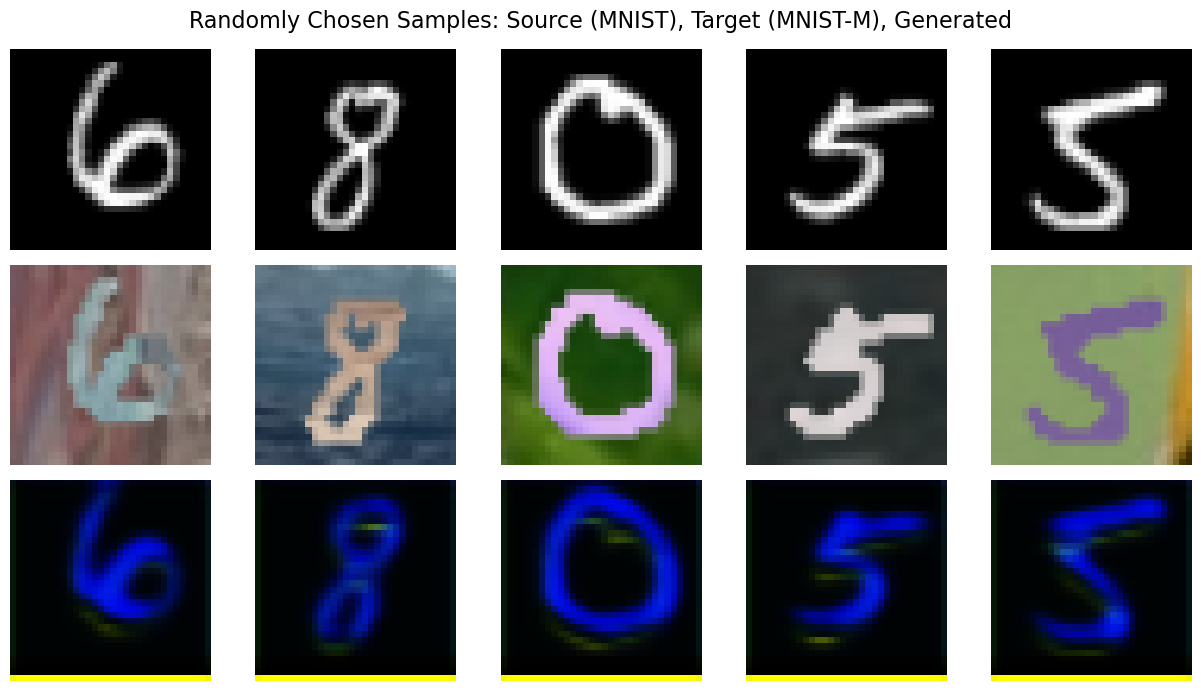

In [40]:
import random
import matplotlib.pyplot as plt
import torch

num_samples = 5
indices = random.sample(range(len(mnist_test)), num_samples)

mnist_images = []
mnistm_images = []
fake_images = []

# load model:
checkpoints = glob.glob('model_checkpoints/checkpoint_epoch_34.pth')
if not checkpoints:
    raise FileNotFoundError("No checkpoints found.")
else:
    latest_checkpoint = sorted(checkpoints, key=lambda x: int(x.split('_')[-1].split('.')[0]))[-1]
    print(f"Loading checkpoint: {latest_checkpoint}")

    # Load checkpoint
    checkpoint = torch.load(latest_checkpoint)

    # Load models
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    classifier.load_state_dict(checkpoint['classifier_state_dict'])

    # Load optimizers
    optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
    optimizer_D.load_state_dict(checkpoint['optimizer_D_state_dict'])
    optimizer_T.load_state_dict(checkpoint['optimizer_T_state_dict'])

    # Load schedulers
    scheduler_G.load_state_dict(checkpoint['scheduler_G_state_dict'])
    scheduler_D.load_state_dict(checkpoint['scheduler_D_state_dict'])
    scheduler_T.load_state_dict(checkpoint['scheduler_T_state_dict'])


generator.eval()

for idx in indices:
    mnist_img, label = mnist_test[idx]
    mnistm_img, label = mnistm_test[idx]

    mnist_images.append(mnist_img)
    mnistm_images.append(mnistm_img)

    img = mnist_img.unsqueeze(0).to(device)
    z = ((torch.rand(1, noise_dim, device=device) * 2)-1)
    with torch.no_grad():
        fake_img = generator(img, z).squeeze(0).cpu() 

    fake_images.append(fake_img)

# denormalize images for display
def denormalize(img_tensor):
    img_tensor = img_tensor * 0.5 + 0.5  # reverse normalization
    return img_tensor.permute(1, 2, 0).numpy()

# plotting
fig, axes = plt.subplots(3, num_samples, figsize=(num_samples * 2.5, 7))
titles = ['MNIST', 'MNIST-M', 'Generated']

for i in range(num_samples):
    # Row 1: MNIST
    axes[0, i].imshow(denormalize(mnist_images[i]))
    axes[0, i].axis('off')

    # Row 2: MNIST-M
    axes[1, i].imshow(denormalize(mnistm_images[i]))
    axes[1, i].axis('off')

    # Row 3: Fake
    axes[2, i].imshow(denormalize(fake_images[i]))
    axes[2, i].axis('off')

# Label rows
for row in range(3):
    axes[row, 0].set_ylabel(titles[row], fontsize=14)

plt.suptitle("Randomly Chosen Samples: Source (MNIST), Target (MNIST-M), Generated", fontsize=16)
plt.tight_layout()
plt.show()

# plotting

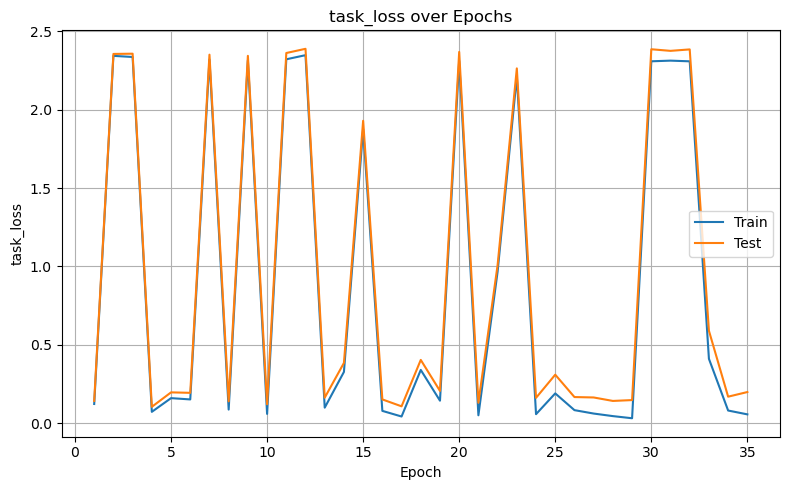

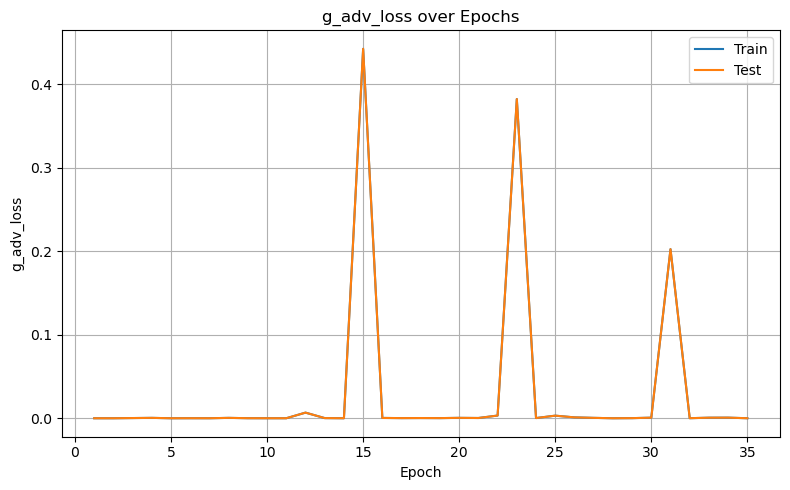

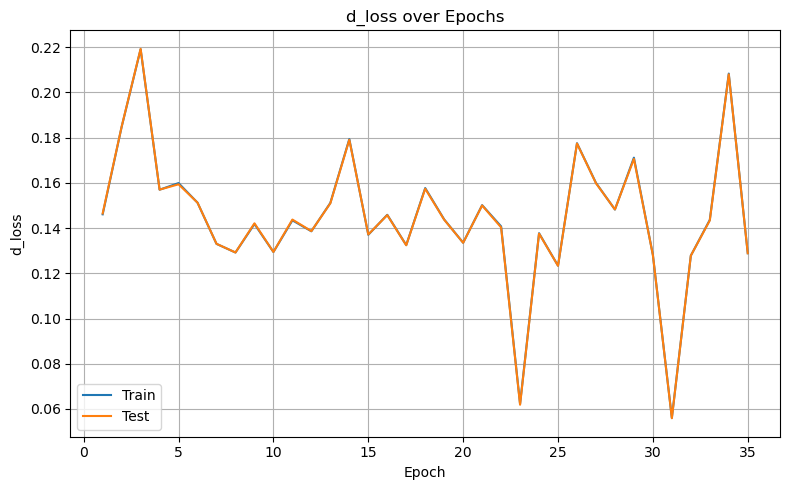

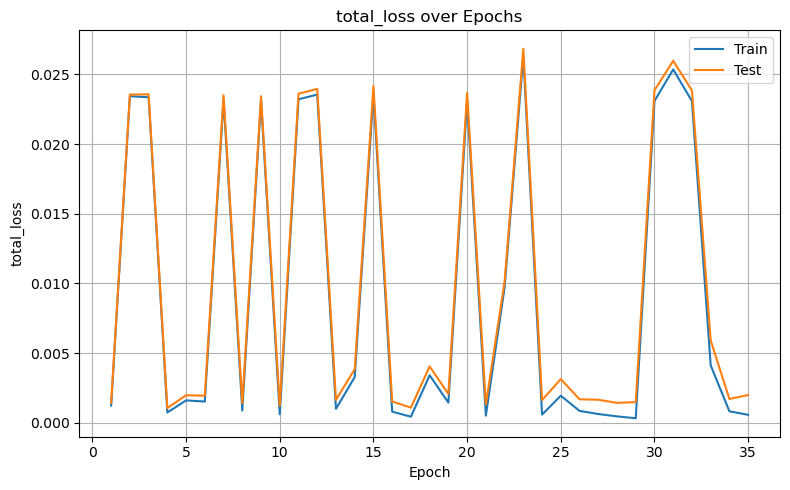

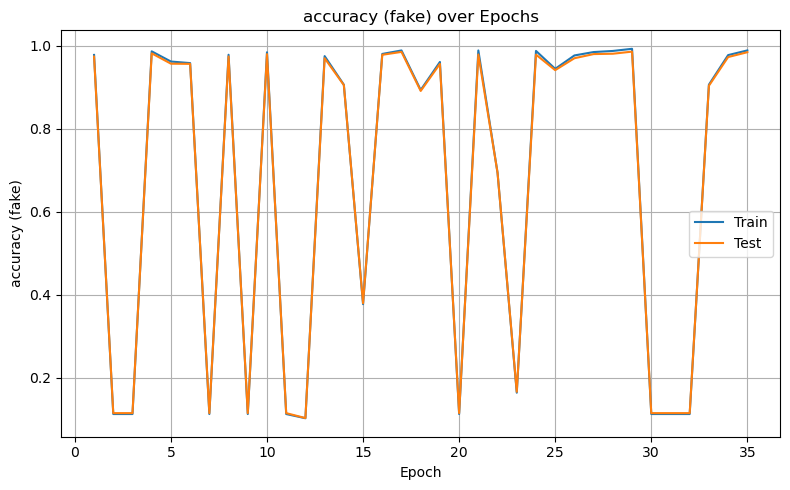

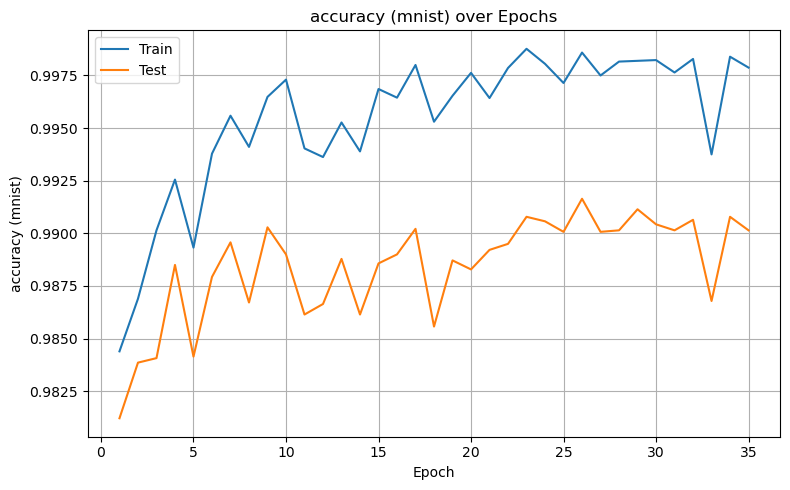

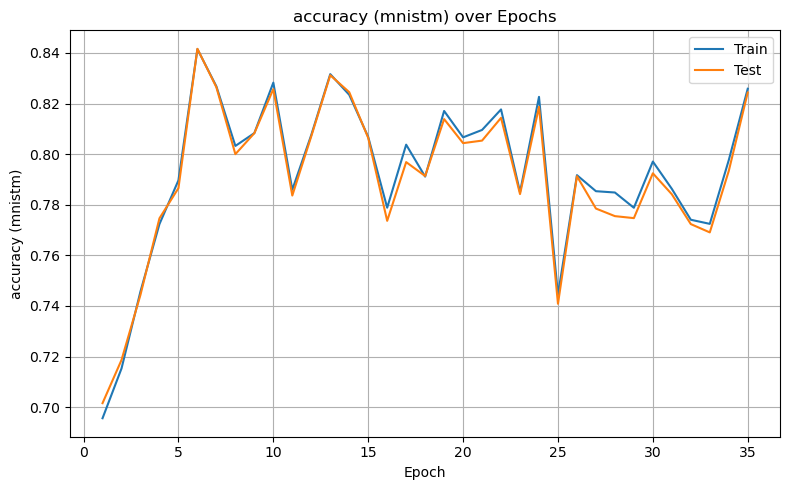


metrics from the last epoch (epoch 35):
---------------------------------------------
task_loss            | Train: 0.05703206 | Test: 0.19931331
g_adv_loss           | Train: 0.00001866 | Test: 0.00001866
d_loss               | Train: 0.12890497 | Test: 0.12890423
total_loss           | Train: 0.00057053 | Test: 0.00199334
accuracy (fake)      | Train: 0.98860714 | Test: 0.98428571
accuracy (mnist)     | Train: 0.99787500 | Test: 0.99014286
accuracy (mnistm)    | Train: 0.82585714 | Test: 0.82435714


In [42]:
import os
import torch
import matplotlib.pyplot as plt

checkpoint_dir = 'model_checkpoints'

metric_names = ["task_loss", "g_adv_loss", "d_loss", "total_loss",
    "accuracy (fake)", "accuracy (mnist)", "accuracy (mnistm)"
]

train_metrics = {metric: [] for metric in metric_names}
test_metrics = {metric: [] for metric in metric_names}
epochs = []


# load from checkpoint folder:
checkpoint_files = sorted(
    [f for f in os.listdir(checkpoint_dir) if f.startswith("checkpoint_epoch_")],
    key=lambda x: int(x.split('_')[-1].split('.')[0])
)

for ckpt_file in checkpoint_files:
    path = os.path.join(checkpoint_dir, ckpt_file)
    ckpt = torch.load(path, map_location='cpu')  # Adjust device if needed

    epoch = ckpt['epoch']
    epochs.append(epoch)

    for metric in metric_names:
        train_metrics[metric].append(ckpt['train_results'][metric])
        test_metrics[metric].append(ckpt['test_results'][metric])

# Plotting
for metric in metric_names:
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_metrics[metric], label='Train')
    plt.plot(epochs, test_metrics[metric], label='Test')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.title(f'{metric} over Epochs')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


print(f"\nmetrics from the last epoch (epoch {epochs[-1]}):\n" + "-"*45)
for metric in metric_names:
    train_val = train_metrics[metric][-1]
    test_val = test_metrics[metric][-1]
    print(f"{metric:20} | Train: {train_val:.8f} | Test: {test_val:.8f}")


Loading checkpoint: model_checkpoints/checkpoint_epoch_35.pth


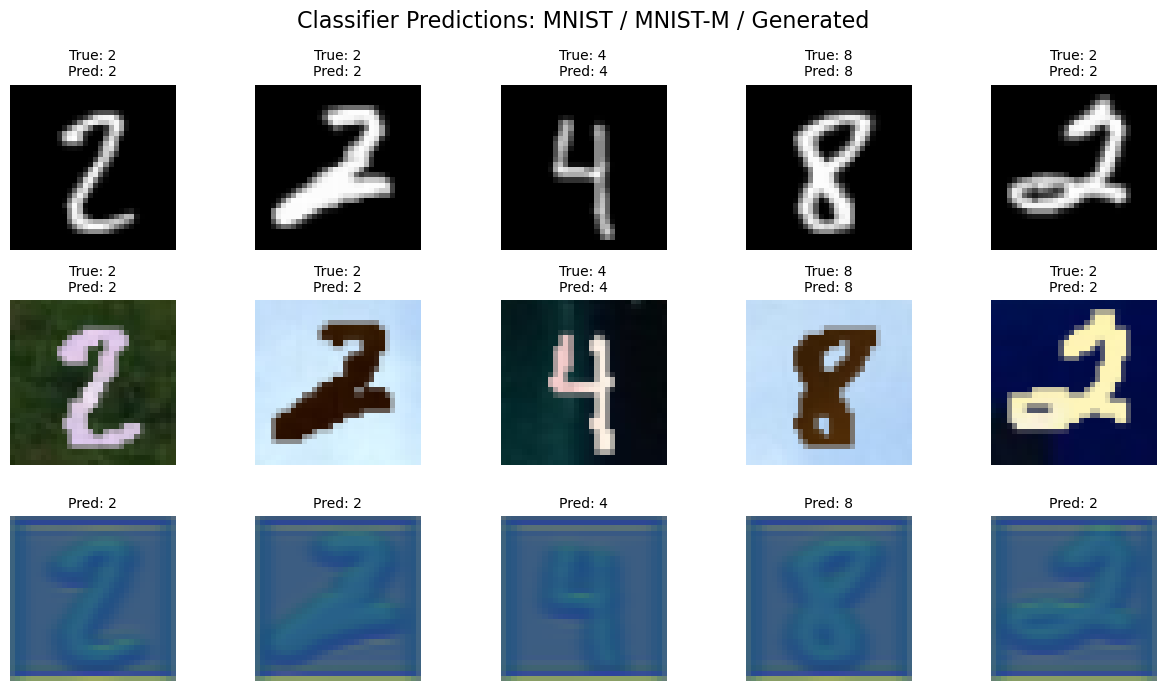

In [154]:
import random
import matplotlib.pyplot as plt
import torch
import glob

num_samples = 5
indices = random.sample(range(len(mnist_test)), num_samples)

mnist_images = []
mnistm_images = []
fake_images = []

mnist_true_labels = []
mnistm_true_labels = []

mnist_preds = []
mnistm_preds = []
fake_preds = []

# load model:
checkpoints = glob.glob('model_checkpoints/checkpoint_epoch_35.pth')
if not checkpoints:
    raise FileNotFoundError("no checkpoints found.")
else:
    latest_checkpoint = sorted(checkpoints, key=lambda x: int(x.split('_')[-1].split('.')[0]))[-1]
    print(f"Loading checkpoint: {latest_checkpoint}")

    # Load checkpoint
    checkpoint = torch.load(latest_checkpoint, map_location=device)

    # Load models
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    classifier.load_state_dict(checkpoint['classifier_state_dict'])

    generator.eval()
    classifier.eval()

for idx in indices:
    mnist_img, label = mnist_test[idx]
    mnistm_img, _ = mnistm_test[idx]  # label same as MNIST

    mnist_images.append(mnist_img)
    mnistm_images.append(mnistm_img)
    mnist_true_labels.append(label)
    mnistm_true_labels.append(label)

    img = mnist_img.unsqueeze(0).to(device)
    z = ((torch.rand(1, noise_dim, device=device) * 2)-1)
    with torch.no_grad():
        fake_img = generator(img, z).squeeze(0).cpu()
        fake_pred = classifier(fake_img.unsqueeze(0).to(device))
        mnist_pred = classifier(img)
        mnistm_pred = classifier(mnistm_img.unsqueeze(0).to(device))

    fake_images.append(fake_img)
    mnist_preds.append(torch.argmax(mnist_pred, dim=1).item())
    mnistm_preds.append(torch.argmax(mnistm_pred, dim=1).item())
    fake_preds.append(torch.argmax(fake_pred, dim=1).item())

def denormalize(img_tensor):
    img_tensor = img_tensor * 0.5 + 0.5  # reverse normalization
    return img_tensor.permute(1, 2, 0).numpy()

fig, axes = plt.subplots(3, num_samples, figsize=(num_samples * 2.5, 7))
titles = ['MNIST', 'MNIST-M', 'Generated']

for i in range(num_samples):
    # Row 1: MNIST
    axes[0, i].imshow(denormalize(mnist_images[i]))
    axes[0, i].set_title(f'True: {mnist_true_labels[i]}\nPred: {mnist_preds[i]}', fontsize=10)
    axes[0, i].axis('off')

    # Row 2: MNIST-M
    axes[1, i].imshow(denormalize(mnistm_images[i]))
    axes[1, i].set_title(f'True: {mnistm_true_labels[i]}\nPred: {mnistm_preds[i]}', fontsize=10)
    axes[1, i].axis('off')

    # Row 3: Fake
    axes[2, i].imshow(denormalize(fake_images[i]))
    axes[2, i].set_title(f'Pred: {fake_preds[i]}', fontsize=10)
    axes[2, i].axis('off')

# Label rows
for row in range(3):
    axes[row, 0].set_ylabel(titles[row], fontsize=14)

plt.suptitle("Classifier Predictions: MNIST / MNIST-M / Generated", fontsize=16)
plt.tight_layout()
plt.show()